In [65]:
import os
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.colors
import matplotlib.pyplot as plt
sb.set()
import plotly.offline as py
import plotly.figure_factory as ff
import plotly.graph_objs as go
from plotly import tools
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.mplot3d import Axes3D
from decimal import Decimal

# Intialize

Our experiment will be a quartenary composition of Polymers with x_1,x_2,x_3,x_4 be the composition of each polymer D18-Cl (Donor) and Y6, Y7, L8-BO (Acceptors). Because x_1 + x_2 + x_3 + x_4 = 1, the degree of freedom of the system is 3. Thus the search space is x_1 + x_2 + x_3 < 1 with x_4 = 1 - (x_1 + x_2 + x_3)

We will plot the search space:

In [66]:
def plot_domain(point, name, elevs=30, azims=30, save=True):
    # Define the vertices of the tetrahedron
    vertices = np.array([[0, 0, 0],    # Vertex A
                         [1, 0, 0],    # Vertex B
                         [0, 1, 0],    # Vertex C
                         [0, 0, 1]])   # Vertex D

    # Define the faces of the tetrahedron using the vertices
    faces = [[vertices[j] for j in [0, 1, 2]],  # Face ABC
             [vertices[j] for j in [0, 1, 3]],  # Face ABD
             [vertices[j] for j in [0, 2, 3]],  # Face ACD
             [vertices[j] for j in [1, 2, 3]]]  # Face BCD

    # Create a figure
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Create a 3D polygon collection for the tetrahedron
    tetrahedron = Poly3DCollection(faces, alpha=0.5, facecolors='cyan', linewidths=1, edgecolors='r')
    ax.add_collection3d(tetrahedron)
    
    try:
        display_points = np.array(point)
        ax.scatter(display_points[:, 0], display_points[:, 1], display_points[:, 2], color='red', s=50)  # s is the size of points
    except:
        pass
    
    # Set limits
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])
    
    # Label the axes
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('x3')

    # Set background color to transparent
    fig.patch.set_alpha(0.0)  # Set figure background transparency
    
    ax.view_init(elev=elevs, azim=azims)  # Change elevation and azimuth
    plt.tight_layout()

    # Show and save the plot
    if save:
        folder_path = "Visualisation"  # Replace with your desired folder path
        file_name = name+'.svg'
        full_path = os.path.join(folder_path, file_name)
        os.makedirs(folder_path, exist_ok=True)
        plt.savefig(full_path, format='svg')
    plt.show()

In [122]:
def plot_domain_two(point, name, elevs=(30, 0), azims=(30, 0), save=True, text = ['a','b']):
    # Define the vertices of the tetrahedron
    vertices = np.array([[0, 0, 0],    # Vertex A
                         [1, 0, 0],    # Vertex B
                         [0, 1, 0],    # Vertex C
                         [0, 0, 1]])   # Vertex D

    # Define the faces of the tetrahedron using the vertices
    faces = [[vertices[j] for j in [0, 1, 2]],  # Face ABC
             [vertices[j] for j in [0, 1, 3]],  # Face ABD
             [vertices[j] for j in [0, 2, 3]],  # Face ACD
             [vertices[j] for j in [1, 2, 3]]]  # Face BCD

    # Create a figure with two subplots arranged side by side
    fig = plt.figure(figsize=(13, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')

    for ax, elev, azim, label in zip([ax1, ax2], elevs, azims, text):
        # Create a 3D polygon collection for the tetrahedron
        tetrahedron = Poly3DCollection(faces, alpha=0.5, facecolors='cyan', linewidths=1, edgecolors='r')
        ax.add_collection3d(tetrahedron)
        
        try:
            display_points = np.array(point)
            ax.scatter(display_points[:, 0], display_points[:, 1], display_points[:, 2], color='red', s=50)
        except:
            pass
        
        # Set limits
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_zlim([0, 1])
        
        # Label the axes
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_zlabel('x3')
        
        # Set viewing angles
        ax.view_init(elev=elev, azim=azim)
        ax.text2D(0.95, 0.95, label, transform=ax.transAxes, fontsize=14, va='top', ha='right', color='black')
    
    # Adjust the layout to avoid overlap
    plt.tight_layout()

    # Show and save the plot
    if save:
        folder_path = "Visualisation"  # Replace with your desired folder path
        file_name = name+'.svg'
        full_path = os.path.join(folder_path, file_name)
        os.makedirs(folder_path, exist_ok=True)
        plt.savefig(full_path, format='svg')
    plt.show()

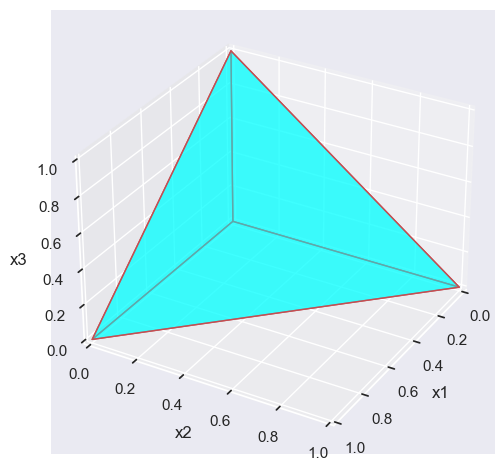

In [67]:
plot_domain([], 'domain')

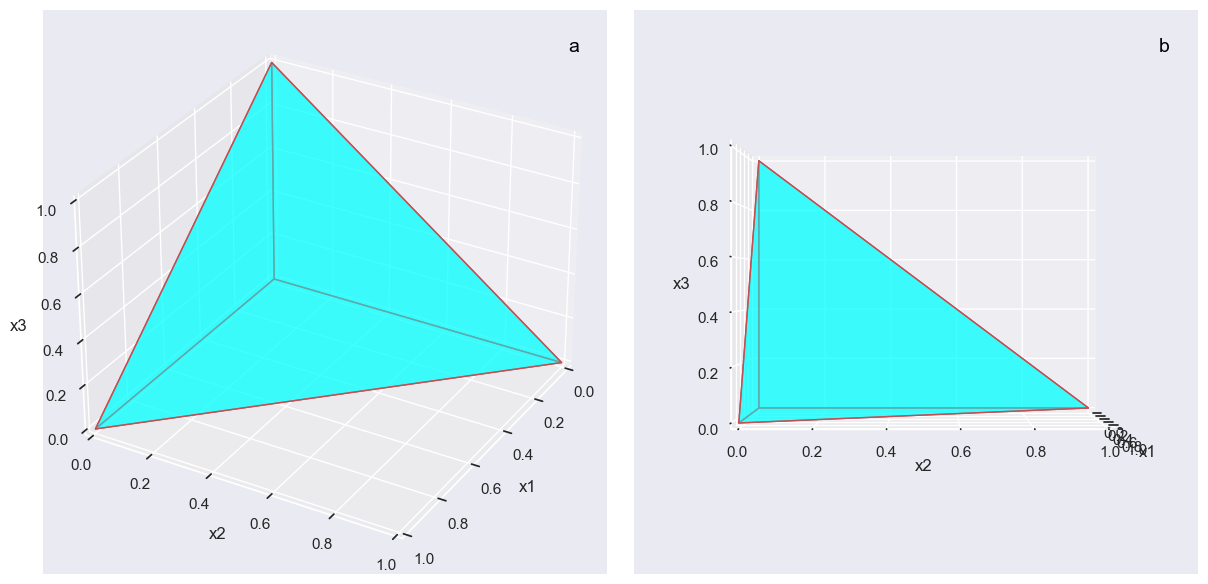

In [115]:
plot_domain_two(point=[], name="tetrahedron_plot", save = False)

# Initial Dataset

In [68]:
partition = 11
combination = [[0,1],[0,2],[0,3],[1,2],[1,3],[2,3]]
initial_points = []
for a in range(10):
    initial_points.append([0.25,0.25,0.25,0.25]) #For consistency test
for a in range(6):
    for b in range(partition):
        point = [0.,0.,0.,0.]
        point[combination[a][0]] = round(b/ (partition - 1), 10)
        point[combination[a][1]] = round(1 - b/(partition-1),10)
        if point not in initial_points:
            initial_points.append(point)
        
initial_points

[[0.25, 0.25, 0.25, 0.25],
 [0.25, 0.25, 0.25, 0.25],
 [0.25, 0.25, 0.25, 0.25],
 [0.25, 0.25, 0.25, 0.25],
 [0.25, 0.25, 0.25, 0.25],
 [0.25, 0.25, 0.25, 0.25],
 [0.25, 0.25, 0.25, 0.25],
 [0.25, 0.25, 0.25, 0.25],
 [0.25, 0.25, 0.25, 0.25],
 [0.25, 0.25, 0.25, 0.25],
 [0.0, 1.0, 0.0, 0.0],
 [0.1, 0.9, 0.0, 0.0],
 [0.2, 0.8, 0.0, 0.0],
 [0.3, 0.7, 0.0, 0.0],
 [0.4, 0.6, 0.0, 0.0],
 [0.5, 0.5, 0.0, 0.0],
 [0.6, 0.4, 0.0, 0.0],
 [0.7, 0.3, 0.0, 0.0],
 [0.8, 0.2, 0.0, 0.0],
 [0.9, 0.1, 0.0, 0.0],
 [1.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 1.0, 0.0],
 [0.1, 0.0, 0.9, 0.0],
 [0.2, 0.0, 0.8, 0.0],
 [0.3, 0.0, 0.7, 0.0],
 [0.4, 0.0, 0.6, 0.0],
 [0.5, 0.0, 0.5, 0.0],
 [0.6, 0.0, 0.4, 0.0],
 [0.7, 0.0, 0.3, 0.0],
 [0.8, 0.0, 0.2, 0.0],
 [0.9, 0.0, 0.1, 0.0],
 [0.0, 0.0, 0.0, 1.0],
 [0.1, 0.0, 0.0, 0.9],
 [0.2, 0.0, 0.0, 0.8],
 [0.3, 0.0, 0.0, 0.7],
 [0.4, 0.0, 0.0, 0.6],
 [0.5, 0.0, 0.0, 0.5],
 [0.6, 0.0, 0.0, 0.4],
 [0.7, 0.0, 0.0, 0.3],
 [0.8, 0.0, 0.0, 0.2],
 [0.9, 0.0, 0.0, 0.1],
 [0.0, 0.1, 0.9, 

In [69]:
len(initial_points)

68

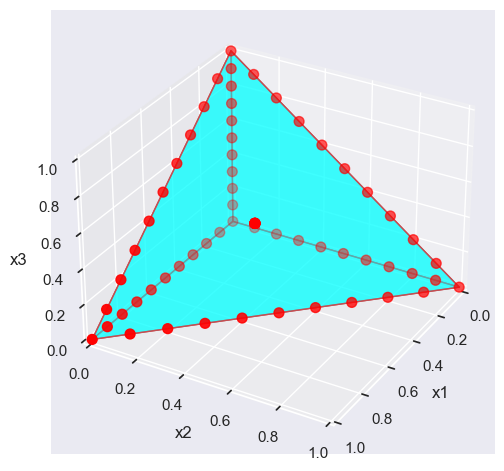

In [70]:
plot_domain(initial_points, 'initial')

## Opentron Code to Obtain Initial Dataset

In [71]:
'''
Setup:

Compartment 5: 200ul wellplate
Compartment 6: Tuberack 4x50ml + 6x15ml
    A3 = D18_Cl
    A4 = Y6
    B3 = Y7
    B4 = L8_BO
Compartment 8: Tiprack 300ul
'''
# Opentron_Initial.py content:
'''
from opentrons import protocol_api
import numpy as np

metadata = {
    "apiLevel": "2.13",
}


def run(protocol: protocol_api.ProtocolContext):
    resource = protocol.load_labware("opentrons_10_tuberack_falcon_4x50ml_6x15ml_conical", 6)
    plate = protocol.load_labware("nest_96_wellplate_200ul_flat", 5)
    tipracksmall = protocol.load_labware("opentrons_96_tiprack_300ul", 8)
    pipettesmall = protocol.load_instrument("p300_single_gen2", "left")

    # Constant
    tip_max_volume = 300
    aspirate_dispense_rate = 1.5
    well_volume = 160

    # Initialiation of well-plate content and allocation
    partition = 7
    combination = [[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]
    initial_points = []
    for a in range(10):
        initial_points.append([0.25, 0.25, 0.25, 0.25])  # For consistency test
    for a in range(6):
        for b in range(partition):
            point = [0., 0., 0., 0.]
            point[combination[a][0]] = round(b / (partition - 1), 10)
            point[combination[a][1]] = round(1 - b / (partition - 1), 10)
            if point not in initial_points:
                initial_points.append(point)
    run_point = initial_points

    # Initialization of Sample Locations
    rows = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
    columns = list(range(1, 13))
    nrows = len(rows)
    ncols = len(columns)

    well_names = np.zeros([nrows, ncols]).astype("object")
    for i, row in enumerate(rows):
        for j, col in enumerate(columns):
            well_names[i, j] = row + str(col)

    vial_locations = ["A3", "A4", "B3", "B4"]
    # A3 = D18_Cl, A4 = Y6, B3 = Y7, B4 = L8_BO
    protocol.home()

    # Mixing of Polymer
    summary = ''
    current_tip_volume = 0
    overflow = False
    for source_index, source in enumerate(vial_locations):
        # Initialization of new source
        pipettesmall.pick_up_tip(location=tipracksmall)
        pipettesmall.aspirate(volume=tip_max_volume, location=resource[source], rate=aspirate_dispense_rate)
        current_tip_volume = tip_max_volume

        for point_index, point in enumerate(run_point):
            # Checks if number of sample exceeds 96
            if point_index > 95:
                print("Sample point exceed 96, stopping process for source", source, "at point ", point)
                summary += "Sample point exceed 96, stopping process for source " + source + " at point index " + str(
                    point) + "\n"
                overflow = True
                break

            # Checks if dropper content is sufficient, if not, retrieve until max capacity
            if point[source_index] * well_volume > current_tip_volume:
                pipettesmall.aspirate(volume=tip_max_volume - current_tip_volume, location=resource[source],
                                      rate=aspirate_dispense_rate)
                current_tip_volume = tip_max_volume

            # Dispense sample, indicate in output and update corresponding parameters
            name = well_names[point_index // 12, point_index % 12]
            pipettesmall.dispense(volume=point[source_index] * well_volume, location=plate.wells_by_name()[name].top(z=0.5),
                                  rate=aspirate_dispense_rate)

            print("Dispensed", source, "source at", name, ". Volume: ", point[source_index], "of max volume (",
                  point[source_index] * well_volume, "uL)")
            summary += "Dispensed " + source + " source at " + name + ". Volume: " + str(
                point[source_index]) + " of max volume (" + str(point[source_index] * well_volume) + "uL)\n"

            current_tip_volume -= point[source_index] * well_volume

        # Change Source Procedure
        pipettesmall.blow_out(location=resource[source])
        pipettesmall.drop_tip()
    # Finish experimentation Procedure
    protocol.home()
'''
print()

## Initial Analysis

# DOE

In [72]:
DOE_points = []
for a in range(1,partition):
    for b in range(partition):
        for c in range(partition):
            if a + b + c > partition-1:
                break
            point = [0,0,0,0]
            point[0] = round(a / (partition - 1), 10)
            point[1] = round(b / (partition - 1), 10)
            point[2] = round(c / (partition - 1), 10)
            point[3] = round((partition-a-b-c-1) / (partition - 1),10)
            DOE_points.append(point)

In [73]:
len(DOE_points)

220

In [74]:
DOE_points

[[0.1, 0.0, 0.0, 0.9],
 [0.1, 0.0, 0.1, 0.8],
 [0.1, 0.0, 0.2, 0.7],
 [0.1, 0.0, 0.3, 0.6],
 [0.1, 0.0, 0.4, 0.5],
 [0.1, 0.0, 0.5, 0.4],
 [0.1, 0.0, 0.6, 0.3],
 [0.1, 0.0, 0.7, 0.2],
 [0.1, 0.0, 0.8, 0.1],
 [0.1, 0.0, 0.9, 0.0],
 [0.1, 0.1, 0.0, 0.8],
 [0.1, 0.1, 0.1, 0.7],
 [0.1, 0.1, 0.2, 0.6],
 [0.1, 0.1, 0.3, 0.5],
 [0.1, 0.1, 0.4, 0.4],
 [0.1, 0.1, 0.5, 0.3],
 [0.1, 0.1, 0.6, 0.2],
 [0.1, 0.1, 0.7, 0.1],
 [0.1, 0.1, 0.8, 0.0],
 [0.1, 0.2, 0.0, 0.7],
 [0.1, 0.2, 0.1, 0.6],
 [0.1, 0.2, 0.2, 0.5],
 [0.1, 0.2, 0.3, 0.4],
 [0.1, 0.2, 0.4, 0.3],
 [0.1, 0.2, 0.5, 0.2],
 [0.1, 0.2, 0.6, 0.1],
 [0.1, 0.2, 0.7, 0.0],
 [0.1, 0.3, 0.0, 0.6],
 [0.1, 0.3, 0.1, 0.5],
 [0.1, 0.3, 0.2, 0.4],
 [0.1, 0.3, 0.3, 0.3],
 [0.1, 0.3, 0.4, 0.2],
 [0.1, 0.3, 0.5, 0.1],
 [0.1, 0.3, 0.6, 0.0],
 [0.1, 0.4, 0.0, 0.5],
 [0.1, 0.4, 0.1, 0.4],
 [0.1, 0.4, 0.2, 0.3],
 [0.1, 0.4, 0.3, 0.2],
 [0.1, 0.4, 0.4, 0.1],
 [0.1, 0.4, 0.5, 0.0],
 [0.1, 0.5, 0.0, 0.4],
 [0.1, 0.5, 0.1, 0.3],
 [0.1, 0.5, 0.2, 0.2],
 [0.1, 0.5,

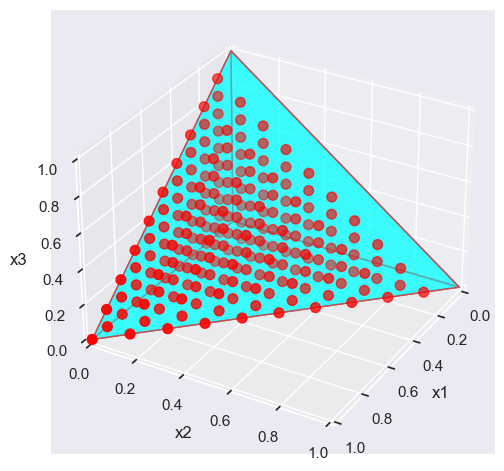

In [75]:
plot_domain(DOE_points, 'DOE')

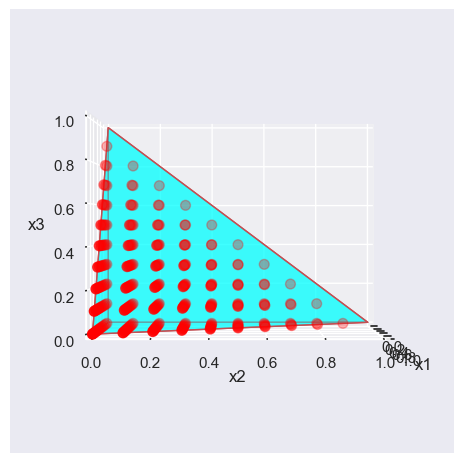

In [76]:
plot_domain(DOE_points, 'DOE_1',0,0)

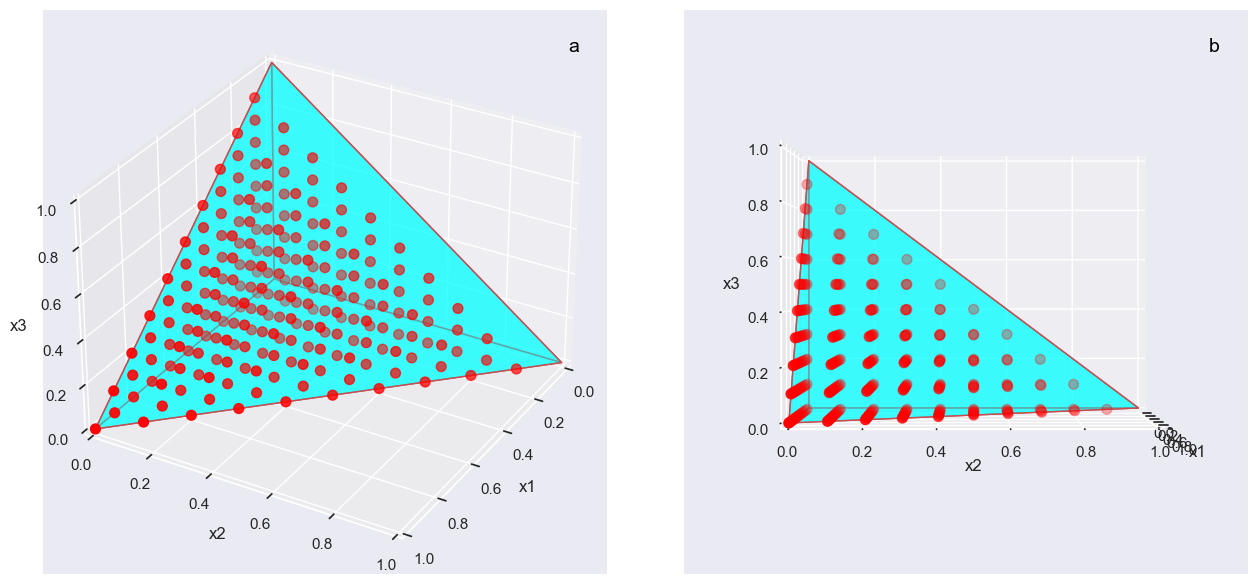

In [123]:
plot_domain_two(DOE_points, 'DOE_twin')

In [77]:
DOE_points_wihtout_initial = [item for item in DOE_points if item not in initial_points]
DOE_points_wihtout_initial

[[0.1, 0.0, 0.1, 0.8],
 [0.1, 0.0, 0.2, 0.7],
 [0.1, 0.0, 0.3, 0.6],
 [0.1, 0.0, 0.4, 0.5],
 [0.1, 0.0, 0.5, 0.4],
 [0.1, 0.0, 0.6, 0.3],
 [0.1, 0.0, 0.7, 0.2],
 [0.1, 0.0, 0.8, 0.1],
 [0.1, 0.1, 0.0, 0.8],
 [0.1, 0.1, 0.1, 0.7],
 [0.1, 0.1, 0.2, 0.6],
 [0.1, 0.1, 0.3, 0.5],
 [0.1, 0.1, 0.4, 0.4],
 [0.1, 0.1, 0.5, 0.3],
 [0.1, 0.1, 0.6, 0.2],
 [0.1, 0.1, 0.7, 0.1],
 [0.1, 0.1, 0.8, 0.0],
 [0.1, 0.2, 0.0, 0.7],
 [0.1, 0.2, 0.1, 0.6],
 [0.1, 0.2, 0.2, 0.5],
 [0.1, 0.2, 0.3, 0.4],
 [0.1, 0.2, 0.4, 0.3],
 [0.1, 0.2, 0.5, 0.2],
 [0.1, 0.2, 0.6, 0.1],
 [0.1, 0.2, 0.7, 0.0],
 [0.1, 0.3, 0.0, 0.6],
 [0.1, 0.3, 0.1, 0.5],
 [0.1, 0.3, 0.2, 0.4],
 [0.1, 0.3, 0.3, 0.3],
 [0.1, 0.3, 0.4, 0.2],
 [0.1, 0.3, 0.5, 0.1],
 [0.1, 0.3, 0.6, 0.0],
 [0.1, 0.4, 0.0, 0.5],
 [0.1, 0.4, 0.1, 0.4],
 [0.1, 0.4, 0.2, 0.3],
 [0.1, 0.4, 0.3, 0.2],
 [0.1, 0.4, 0.4, 0.1],
 [0.1, 0.4, 0.5, 0.0],
 [0.1, 0.5, 0.0, 0.4],
 [0.1, 0.5, 0.1, 0.3],
 [0.1, 0.5, 0.2, 0.2],
 [0.1, 0.5, 0.3, 0.1],
 [0.1, 0.5, 0.4, 0.0],
 [0.1, 0.6,

In [78]:
len(DOE_points_wihtout_initial)

192

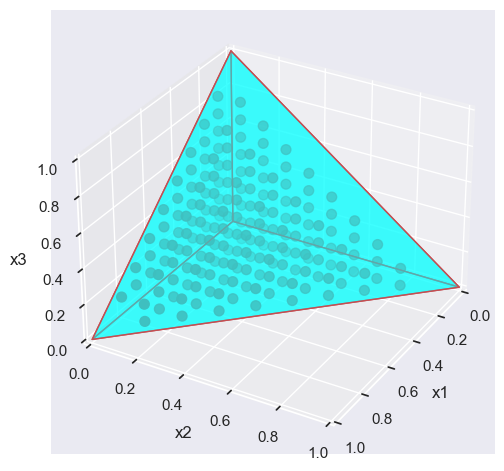

In [79]:
plot_domain(DOE_points_wihtout_initial, 'DOE_no_initial')

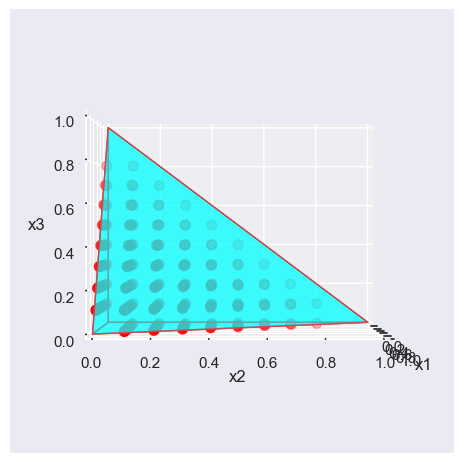

In [80]:
plot_domain(DOE_points_wihtout_initial, 'DOE_no_initial_1',0,0)

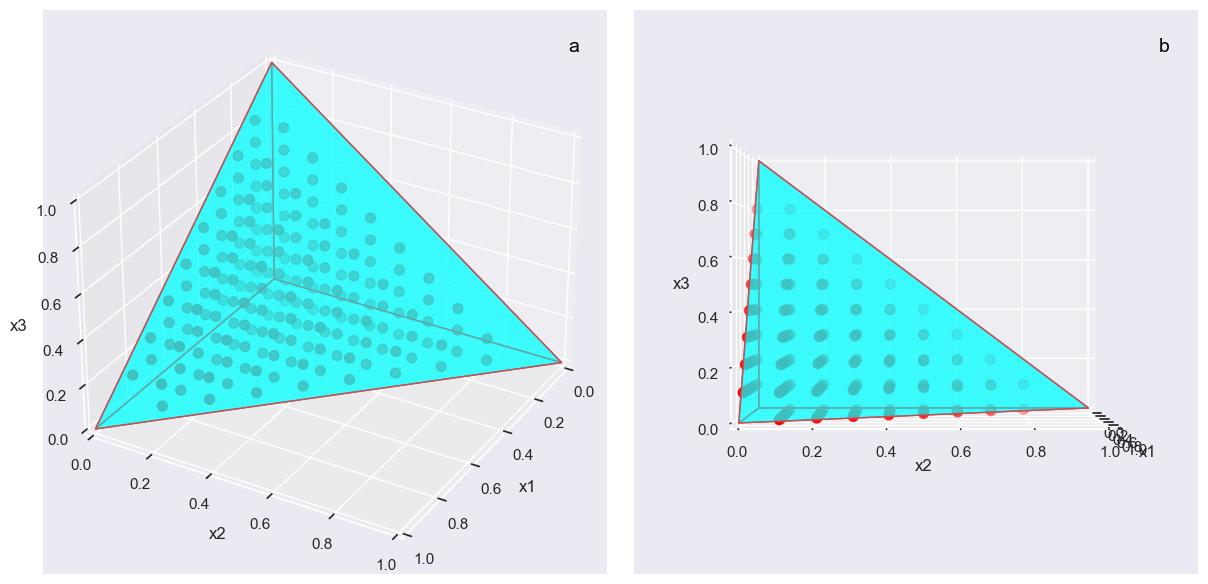

In [117]:
plot_domain_two(DOE_points_wihtout_initial, 'DOE_no_initial_two')

## Opentron for DOE

In [81]:
'''
Setup:

Compartment 5: 200ul wellplate
Compartment 6: Tuberack 4x50ml + 6x15ml
    A3 = D18_Cl
    A4 = Y6
    B3 = Y7
    B4 = L8_BO
Compartment 8: Tiprack 300ul
'''
# Opentron_DOE.py content:
'''
from opentrons import protocol_api
import numpy as np

metadata = {
    "apiLevel": "2.13",
}


def run(protocol: protocol_api.ProtocolContext):
    resource = protocol.load_labware("opentrons_10_tuberack_falcon_4x50ml_6x15ml_conical", 6)
    plate = protocol.load_labware("nest_96_wellplate_200ul_flat", 5)
    tipracksmall = protocol.load_labware("opentrons_96_tiprack_300ul", 8)
    pipettesmall = protocol.load_instrument("p300_single_gen2", "left")

    # Constant
    tip_max_volume = 300
    aspirate_dispense_rate = 1.5
    well_volume = 160
    last_run = 0 #Adjust this for the 2nd (to 96) and 3rd batch (to 192)

    # Initialiation of well-plate content and allocation
    partition = 7
    combination = [[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]
    initial_points = []
    for a in range(10):
        initial_points.append([0.25, 0.25, 0.25, 0.25])  # For consistency test
    for a in range(6):
        for b in range(partition):
            point = [0., 0., 0., 0.]
            point[combination[a][0]] = round(b / (partition - 1), 10)
            point[combination[a][1]] = round(1 - b / (partition - 1), 10)
            if point not in initial_points:
                initial_points.append(point)
    DOE_points = []
    for a in range(1,partition):
        for b in range(partition):
            for c in range(partition):
                if a + b + c > partition-1:
                    break
                point = [0,0,0,0]
                point[0] = round(a / (partition - 1), 10)
                point[1] = round(b / (partition - 1), 10)
                point[2] = round(c / (partition - 1), 10)
                point[3] = round((partition-a-b-c-1) / (partition - 1),10)
                if point not in initial_points:
                    DOE_points.append(point)
    run_point = DOE_points

    # Initialization of Sample Locations
    rows = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
    columns = list(range(1, 13))
    nrows = len(rows)
    ncols = len(columns)

    well_names = np.zeros([nrows, ncols]).astype("object")
    for i, row in enumerate(rows):
        for j, col in enumerate(columns):
            well_names[i, j] = row + str(col)

    vial_locations = ["A3", "A4", "B3", "B4"]
    # A3 = D18_Cl, A4 = Y6, B3 = Y7, B4 = L8_BO
    protocol.home()

    # Mixing of Polymer
    summary = ''
    current_tip_volume = 0
    overflow = False
    for source_index, source in enumerate(vial_locations):
        # Initialization of new source
        pipettesmall.pick_up_tip(location=tipracksmall)
        pipettesmall.aspirate(volume=tip_max_volume, location=resource[source], rate=aspirate_dispense_rate)
        current_tip_volume = tip_max_volume

        for point_index, point in enumerate(run_point[last_run:]):
            # Checks if number of sample exceeds 96
            if point_index > 95:
                print("Sample point exceed 96, stopping process for source", source, "at point ", point)
                summary += "Sample point exceed 96, stopping process for source " + source + " at point index " + str(
                    point) + "\n"
                overflow = True
                break

            # Checks if dropper content is sufficient, if not, retrieve until max capacity
            if point[source_index] * well_volume > current_tip_volume:
                pipettesmall.aspirate(volume=tip_max_volume - current_tip_volume, location=resource[source],
                                      rate=aspirate_dispense_rate)
                current_tip_volume = tip_max_volume

            # Dispense sample, indicate in output and update corresponding parameters
            name = well_names[point_index // 12, point_index % 12]
            pipettesmall.dispense(volume=point[source_index] * well_volume, location=plate.wells_by_name()[name].top(z=0.5),
                                  rate=aspirate_dispense_rate)

            print("Dispensed", source, "source at", name, ". Volume: ", point[source_index], "of max volume (",
                  point[source_index] * well_volume, "uL)")
            summary += "Dispensed " + source + " source at " + name + ". Volume: " + str(
                point[source_index]) + " of max volume (" + str(point[source_index] * well_volume) + "uL)\n"

            current_tip_volume -= point[source_index] * well_volume

        # Change Source Procedure
        pipettesmall.blow_out(location=resource[source])
        pipettesmall.drop_tip()
    # Finish experimentation Procedure
    protocol.home()
'''
print()

## DOE Data Analysis

# Random Sampling

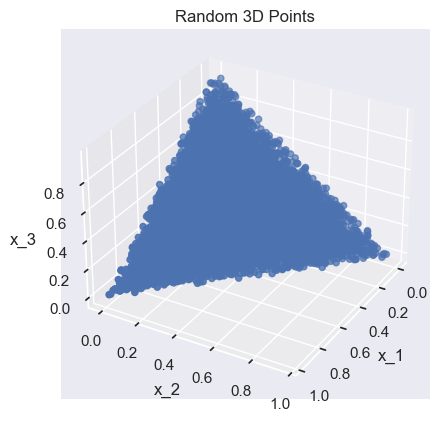

In [82]:
# Number of random arrays to create
freq = 10000

x = []
y = []
z = []

for a in range(freq):
    data = np.random.rand(3)
    total = data[0] + data[1] + data[2]
    while total > 1:
        data = np.random.rand(3)
        total = data[0] + data[1] + data[2]
    x.append(data[0])
    y.append(data[1])
    z.append(data[2])
    
# Create a new figure for 3D plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(x, y, z, c='b', marker='o')

# Add labels
ax.set_xlabel('x_1')
ax.set_ylabel('x_2')
ax.set_zlabel('x_3')
ax.set_title('Random 3D Points')

ax.view_init(elev=30, azim=30)
# Show the plot
folder_path = "Visualisation"  # Replace with your desired folder path
file_name = 'random_attempt2.jpg'
full_path = os.path.join(folder_path, file_name)
os.makedirs(folder_path, exist_ok=True)
plt.savefig(full_path, format='jpg', dpi=300)
plt.show()


In [83]:
import pickle
'''
freq = 192 #Number of iterations DOE needed

x = []
y = []
z = []

for a in range(freq):
    data = np.random.rand(3)
    total = data[0] + data[1] + data[2]
    while total > 1:
        data = np.random.rand(3)
        total = data[0] + data[1] + data[2]
    x.append(data[0])
    y.append(data[1])
    z.append(data[2])
# Save variables to a file
with open('Kernel\Random_generated.pkl', 'wb') as f:
    pickle.dump((x,y,z), f)
'''
    # Import the variables
with open('Kernel\Random_generated.pkl', 'rb') as f:
    random = pickle.load(f)
random

([0.5365744239325677,
  0.23813122905390605,
  0.05479018053540108,
  0.2758109039868646,
  0.2750969021842612,
  0.23404893161533724,
  0.626448712989795,
  0.0917887548265266,
  0.14905397859613467,
  0.5307517684825035,
  0.30556085620044804,
  0.44233768823163466,
  0.5260634269146143,
  0.07337716273933648,
  0.09014210632710795,
  0.5998502637383508,
  0.27945626013376246,
  0.6215182857192462,
  0.15423910971691257,
  0.025519927021546707,
  0.22052372051617597,
  0.03834868792735491,
  0.33870569361778746,
  0.8398328781938715,
  0.418122606021587,
  0.3188651233710782,
  0.4284679141200971,
  0.5224868903783864,
  0.03747775222925953,
  0.030863399378252443,
  0.37391669560135743,
  0.34129241197202,
  0.04750868514818063,
  0.014032887069097555,
  0.45133524585240437,
  0.20526546655740818,
  0.11506909887768835,
  0.39503530367370954,
  0.045905823111876964,
  0.4544290956967537,
  0.47445926103565617,
  0.5874134106271356,
  0.002722533132246352,
  0.17667364800506336,
  0.

In [84]:
random_points = []
for a in range(len(random[0])):
    random_points.append([random[0][a],random[1][a],random[2][a],1-random[0][a]-random[1][a]-random[2][a]])
random_points

[[0.5365744239325677,
  0.11011301097620407,
  0.15045624494671272,
  0.2028563201445155],
 [0.23813122905390605,
  0.24577582486827754,
  0.3461198098458882,
  0.16997313623192822],
 [0.05479018053540108,
  0.07910611865534911,
  0.3157458557380073,
  0.5503578450712425],
 [0.2758109039868646,
  0.012949704814964269,
  0.3863525485828132,
  0.32488684261535794],
 [0.2750969021842612,
  0.27954423180544385,
  0.1392855011215749,
  0.30607336488872006],
 [0.23404893161533724,
  0.18712738898690995,
  0.5358038747048836,
  0.04301980469286926],
 [0.626448712989795,
  0.005727921411423753,
  0.2175071827558298,
  0.15031618284295145],
 [0.0917887548265266,
  0.5520659378241758,
  0.35000229194350374,
  0.006143015405793872],
 [0.14905397859613467,
  0.6641568074061317,
  0.11139998003285956,
  0.07538923396487407],
 [0.5307517684825035,
  0.05897063464391428,
  0.1667141303475297,
  0.24356346652605254],
 [0.30556085620044804,
  0.12120696934520614,
  0.26061653424504694,
  0.312615640209

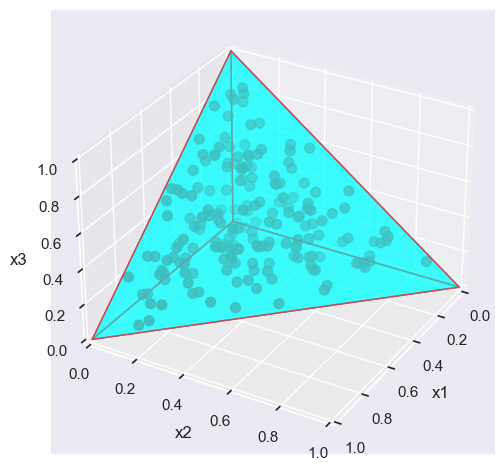

In [85]:
plot_domain(random_points, 'random_points')

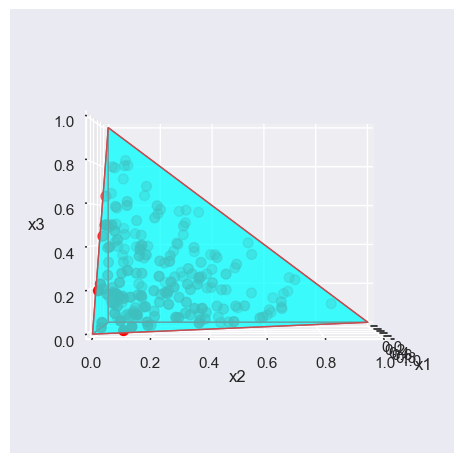

In [86]:
plot_domain(random_points, 'random_points_1',0,0)

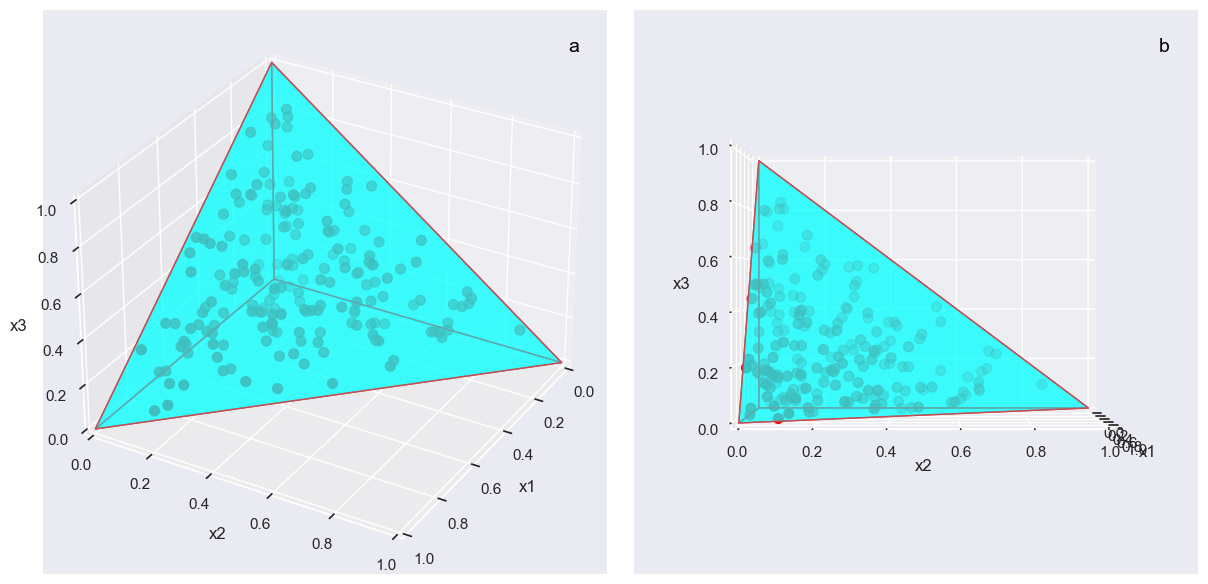

In [119]:
plot_domain_two(random_points, 'random_points_two')

In [87]:
len(random_points)

192

## Opentron Code for Random Sampling

In [88]:
'''
Setup:

Compartment 5: 200ul wellplate
Compartment 6: Tuberack 4x50ml + 6x15ml
    A3 = D18_Cl
    A4 = Y6
    B3 = Y7
    B4 = L8_BO
Compartment 8: Tiprack 300ul
'''
#Opentron_Random.py content:
'''
from opentrons import protocol_api
import numpy as np

metadata = {
    "apiLevel": "2.13",
}


def run(protocol: protocol_api.ProtocolContext):
    resource = protocol.load_labware("opentrons_10_tuberack_falcon_4x50ml_6x15ml_conical", 6)
    plate = protocol.load_labware("nest_96_wellplate_200ul_flat", 5)
    tipracksmall = protocol.load_labware("opentrons_96_tiprack_300ul", 8)
    pipettesmall = protocol.load_instrument("p300_single_gen2", "left")

    # Constant
    tip_max_volume = 300
    aspirate_dispense_rate = 1.5
    well_volume = 160
    last_run = 0 #Adjust this for the 2nd (to 96) and 3rd batch (to 192)

    # Initialiation of well-plate content and allocation
    run_point = [[0.5365744239325677,  0.11011301097620407,  0.15045624494671272,  0.2028563201445155],
 [0.23813122905390605,  0.24577582486827754,  0.3461198098458882,  0.16997313623192822],
 [0.05479018053540108,  0.07910611865534911,  0.3157458557380073,  0.5503578450712425],
 [0.2758109039868646,  0.012949704814964269,  0.3863525485828132,  0.32488684261535794],
 [0.2750969021842612,  0.27954423180544385,  0.1392855011215749,  0.30607336488872006],
 [0.23404893161533724,  0.18712738898690995,  0.5358038747048836,  0.04301980469286926],
 [0.626448712989795,  0.005727921411423753,  0.2175071827558298,  0.15031618284295145],
 [0.0917887548265266,  0.5520659378241758,  0.35000229194350374,  0.006143015405793872],
 [0.14905397859613467,  0.6641568074061317,  0.11139998003285956,  0.07538923396487407],
 [0.5307517684825035,  0.05897063464391428,  0.1667141303475297,  0.24356346652605254],
 [0.30556085620044804,  0.12120696934520614,  0.26061653424504694,  0.3126156402092989],
 [0.44233768823163466,  0.05750452320444399,  0.10231326803097807,  0.3978445205329433],
 [0.5260634269146143,  0.033608030299325464,  0.3940429180152706,  0.04628562477078968],
 [0.07337716273933648,  0.03430774390470814,  0.5047507003762045,  0.38756439297975087],
 [0.09014210632710795,  0.38184975832842893,  0.17954072945243893,  0.3484674058920242],
 [0.5998502637383508,  0.16595933501297555,  0.10741928970118042,  0.1267711115474932],
 [0.27945626013376246,  0.40440746571469255,  0.21219926022479485,  0.10393701392675014],
 [0.6215182857192462,  0.27679915629012664,  0.057463008880311084,  0.044219549110316114],
 [0.15423910971691257,  0.07094675072733314,  0.4517404711145867,  0.3230736684411676],
 [0.025519927021546707,  0.674837641297807,  0.14870494390473976,  0.15093748777590654],
 [0.22052372051617597,  0.09348390572496545,  0.04458171780253428,  0.6414106559563243],
 [0.03834868792735491,  0.2900195850385626,  0.4498440686093148,  0.22178765842476766],
 [0.33870569361778746,  0.12897934273576894,  0.15390603201859043,  0.37840893162785316],
 [0.8398328781938715,  0.0991048848753252,  0.006845847013376427,  0.05421638991742683],
 [0.418122606021587,  0.0758638775500361,  0.15051227223265462,  0.35550124419572227],
 [0.3188651233710782,  0.5923994790294821,  0.04230155576356798,  0.046433841835871736],
 [0.4284679141200971,  0.253852281090007,  0.22099344090748374,  0.09668636388241214],
 [0.5224868903783864,  0.06922474542463652,  0.22119172922496388,  0.18709663497201323],
 [0.03747775222925953,  0.3946934523838129,  0.34829777507078763,  0.2195310203161399],
 [0.030863399378252443,  0.03595689102002941,  0.025968495227388533,  0.9072112143743296],
 [0.37391669560135743,  0.35558677402916616,  0.24213071106399264,  0.028365819305483764],
 [0.34129241197202,  0.37794218339313357,  0.03490590089923307,  0.24585950373561338],
 [0.04750868514818063,  0.04036538659813216,  0.11718357632613985,  0.7949423519275474],
 [0.014032887069097555,  0.3320401571738034,  0.36342360799134,  0.29050334776575903],
 [0.45133524585240437,  0.2655420817810792,  0.19589466066212913,  0.08722801170438732],
 [0.20526546655740818,  0.19532665761173817,  0.5965112665937872,  0.002896609237066472],
 [0.11506909887768835,  0.6194067088968177,  0.06981308368453387,  0.19571110854096008],
 [0.39503530367370954,  0.13546369435305772,  0.347473882419023,  0.12202711955420975],
 [0.045905823111876964,  0.10594455020422677,  0.45565889437875007,  0.3924907323051462],
 [0.4544290956967537,  0.3409347675841238,  0.09249764744582378,  0.11213848927329872],
 [0.47445926103565617,  0.4850710115720276,  0.02906040853305114,  0.011409318859265105],
 [0.5874134106271356,  0.01301858805149747,  0.19214828940434758,  0.20741971191701936],
 [0.002722533132246352,  0.05983186310879751,  0.4826947540438642,  0.45475084971509194],
 [0.17667364800506336,  0.294087373702717,  0.49506370818629764,  0.03417527010592203],
 [0.638686118380198,  0.009238491213560462,  0.00850588333711444,  0.34356950706912714],
 [0.12275432222997062,  0.27174036201374707,  0.40270707913619097,  0.20279823662009133],
 [0.07698985000490444,  0.2988285680214353,  0.5114575969065676,  0.11272398506709269],
 [0.30345253274952455,  0.20719436581338335,  0.11663373632952068,  0.3727193651075714],
 [0.10435210220752122,  0.13094436355151784,  0.4484962000991657,  0.31620733414179525],
 [0.009206213288899034,  0.28087658320166375,  0.2571030773538684,  0.4528141261555688],
 [0.12695377697645904,  0.41246094560201774,  0.34909761881507906,  0.11148765860644416],
 [0.0032134850814808935,  0.3486798433708739,  0.5654881219559643,  0.08261854959168091],
 [0.2298209264808153,  0.08346595945519819,  0.6176474823143652,  0.06906563174962133],
 [0.09355447401418149,  0.06674948985513907,  0.8016379599858727,  0.03805807614480672],
 [0.5264162222578186,  0.08442455496747314,  0.14350478406097944,  0.24565443871372883],
 [0.3709328288704984,  0.16044731561497916,  0.35243312888732903,  0.11618672662719343],
 [0.14514300204508646,  0.4204030410590024,  0.3354544837379384,  0.09899947315797275],
 [0.005608439438636537,  0.4991269424383077,  0.07425607714826288,  0.4210085409747929],
 [0.14991522398300006,  0.18195144473536373,  0.0645311766025688,  0.6036021546790674],
 [0.27950222103054967,  0.5820306672619451,  0.03693985528539223,  0.10152725642211302],
 [0.7602352624553499,  0.006451429599214964,  0.19014471665584642,  0.04316859128958872],
 [0.042118770462847066,  0.06415993865915126,  0.3776108480715763,  0.5161104428064254],
 [0.2824382933023655,  0.04254388732055414,  0.5926516164393251,  0.08236620293775532],
 [0.41862185296631915,  0.14651343194690347,  0.4004782372848732,  0.03438647780190418],
 [0.1355602445760824,  0.6669184301283687,  0.07688353865992248,  0.12063778663562641],
 [0.8110162864656387,  0.12682365479433988,  0.023228999590716892,  0.0389310591493045],
 [0.3220273535668704,  0.18979491895194445,  0.04673771523987813,  0.441440012241307],
 [0.14341160395487007,  0.010890985641348938,  0.4891095616748945,  0.3565878487288865],
 [0.4284591314741033,  0.01868358249666424,  0.16102093323713462,  0.39183635279209783],
 [0.2651927038221399,  0.20719145549707663,  0.32025642787131736,  0.20735941280946613],
 [0.028981730160120844,  0.06784280530503284,  0.8301435218528412,  0.07303194268200508],
 [0.35092904808540826,  0.3047973615665551,  0.06396293520592455,  0.28031065514211206],
 [0.358038226713259,  0.36788848580049305,  0.08868666786734003,  0.1853866196189079],
 [0.5668449978759139,  0.05377915716553239,  0.17164698120123667,  0.20772886375731703],
 [0.11429355186104573,  0.4251083379288839,  0.03323815801073138,  0.427359952199339],
 [0.10556173433479799,  0.14215856939475158,  0.332122427349101,  0.4201572689213494],
 [0.653599022079768,  0.0752388826246686,  0.15739987040015202,  0.11376222489541132],
 [0.4083090565409818,  0.2391713224247869,  0.16271453195943975,  0.18980508907479154],
 [0.13399955973384425,  0.19590270928138087,  0.5571823435984553,  0.11291538738631957],
 [0.45186863976951497,  0.23369255779331632,  0.17064774274321448,  0.14379105969395423],
 [0.3420304118980402,  0.3125330993686496,  0.2074015164109625,  0.13803497232234774],
 [0.361216678637573,  0.24237450830077245,  0.17375402833665343,  0.2226547847250011],
 [0.15306778982489144,  0.06581727422949701,  0.3125915687481674,  0.46852336719744414],
 [0.16533672372562302,  0.2215036743838117,  0.30848725351747863,  0.30467234837308665],
 [0.009831520294972473,  0.21874612006330696,  0.20625995895823834,  0.5651624006834822],
 [0.5384114360349483,  0.17311787984558147,  0.013408978442156938,  0.27506170567731325],
 [0.07139938335960783,  0.3013081163187331,  0.575684062086802,  0.05160843823485706],
 [0.21293367252728035,  0.009727137430831312,  0.5010798942357239,  0.2762592958061645],
 [0.018790424360398683,  0.2736073807184337,  0.5697074875988618,  0.1378947073223058],
 [0.2685817353258928,  0.5247980167235603,  0.09669418264846252,  0.10992606530208437],
 [0.4915512533797395,  0.11956994905226437,  0.06949665683082962,  0.31938214073716653],
 [0.16666494138641552,  0.02529211509342244,  0.7936428944801479,  0.014400049040014129],
 [0.12065002186319462,  0.20467974768292563,  0.5791633816674013,  0.09550684878647842],
 [0.20246799041928687,  0.2091078123933604,  0.151373786945889,  0.43705041024146374],
 [0.39942933718110485,  0.07119049378189446,  0.2628198335317802,  0.2665603355052205],
 [0.17430040986113082,  0.4452775749233695,  0.07660684361188685,  0.3038151716036128],
 [0.5975202870642692,  0.15136463535887124,  0.16032022131258805,  0.09079485626427153],
 [0.1644164720208232,  0.49440703600560554,  0.3020402954604713,  0.03913619651309996],
 [0.32481465498672224,  0.34861137088732463,  0.2061317122893941,  0.12044226183655904],
 [0.06421582402338055,  0.25361845995095755,  0.366498804762293,  0.3156669112633689],
 [0.2149316064305472,  0.11363100800401438,  0.085295766519915,  0.5861416190455234],
 [0.03590466017308136,  0.10935338549053208,  0.3888137593409242,  0.46592819499546234],
 [0.43862036427855944,  0.047211162622816105,  0.4704070530184745,  0.04376142008014994],
 [0.11025953957222567,  0.35231306117899,  0.05182656041303424,  0.4856008388357501],
 [0.03495771919025903,  0.6964250404831681,  0.23074590458531485,  0.037871335741258005],
 [0.4394560117792885,  0.2824640660170651,  0.04716037109786675,  0.23091955110577966],
 [0.1778209972708391,  0.46373772131132307,  0.01102429718020037,  0.34741698423763745],
 [0.11056593290335726,  0.1515893806137475,  0.696368789903137,  0.041475896579758254],
 [0.32504574905275296,  0.14254733473836034,  0.26041990255083625,  0.27198701365805045],
 [0.24486309130674777,  0.003954684333572489,  0.643569907273593,  0.10761231708608676],
 [0.21825395785467527,  0.3273904776334692,  0.25512241600817664,  0.1992331485036789],
 [0.7478808028045504,  0.14300391152834335,  0.07621505401619044,  0.03290023165091582],
 [0.3870694818851712,  0.055129845667221344,  0.4275846129864739,  0.13021605946113357],
 [0.17712443047269688,  0.38062344379747637,  0.05941892125492909,  0.38283320447489766],
 [0.05674453682328706,  0.38096553498513586,  0.24998945317983512,  0.31230047501174196],
 [0.4593592128305801,  0.012726534836354553,  0.4987481108421823,  0.029166141490883035],
 [0.42798623792683654,  0.36110659859053884,  0.03436639215488668,  0.17654077132773793],
 [0.04789168020236545,  0.13445526311646205,  0.0793570490130533,  0.7382960076681192],
 [0.3002244067482953,  0.007901655446427291,  0.5007852030596698,  0.1910887347456076],
 [0.13373732581045839,  0.25972647008805894,  0.23763176938022368,  0.368904434721259],
 [0.07198194980578154,  0.4882815888625608,  0.281392759758733,  0.15834370157292466],
 [0.3859315354149284,  0.18946324807869452,  0.17626171115956835,  0.2483435053468087],
 [0.4524450559797417,  0.2456938452551608,  0.11194354438003828,  0.1899175543850592],
 [0.18286104411281423,  0.13689828540268545,  0.13497599726298104,  0.5452646732215193],
 [0.001705715525226914,  0.8590903337134737,  0.09558632621192986,  0.04361762454936957],
 [0.7318453248545113,  0.08259827950239906,  0.046377130802391586,  0.1391792648406981],
 [0.4880457769505431,  0.00677961169916752,  0.44537013267904413,  0.059804478671245276],
 [0.2441057388960748,  0.49136370907878935,  0.09449408712118523,  0.17003646490395063],
 [0.06583478036585444,  0.3976435373381787,  0.1814312793010464,  0.35509040299492045],
 [0.062077913532015416,  0.28881490734415416,  0.23689592168476203,  0.4122112574390684],
 [0.21843020297044102,  0.4209546592329336,  0.09292693128368068,  0.26768820651294467],
 [0.09039868851582589,  0.12131081532008614,  0.20092493536007627,  0.5873655608040117],
 [0.6817077343411904,  0.014447706294198226,  0.0361797686070221,  0.2676647907575893],
 [0.5949488672025288,  0.05451306172969794,  0.12011818651334105,  0.23041988455443219],
 [0.11372156700540437,  0.03844296000498737,  0.5862195778889147,  0.2616158951006936],
 [0.0029868008691614767,  0.634225243569981,  0.12610038520463374,  0.2366875703562238],
 [0.1123558626394352,  0.15674823364523593,  0.39272375567052153,  0.33817214804480733],
 [0.45882364727420943,  0.03809532087849954,  0.5007829440690927,  0.002298087778198288],
 [0.4544277321699576,  0.14126367699777975,  0.37995933933068193,  0.024349251501580738],
 [0.40721577070401804,  0.24791033103499327,  0.32136905111109604,  0.02350484714989265],
 [0.02619925725742467,  0.1407150135104397,  0.6505976018656249,  0.18248812736651077],
 [0.010830363881869753,  0.05852722736451399,  0.7364049011322162,  0.19423750762140002],
 [0.08044514754790721,  0.07137207108121779,  0.03909767147455101,  0.809085109896324],
 [0.06870677418839632,  0.4336457490647567,  0.0018590394224923257,  0.4957884373243546],
 [0.08221973407249128,  0.4005253845784136,  0.27366770083800873,  0.2435871805110864],
 [0.06089267045321012,  0.551652755485835,  0.15334343359133273,  0.23411114046962211],
 [0.08673340670192375,  0.35229844435570845,  0.2238026654324473,  0.3371654835099205],
 [0.26439045710029674,  0.32193234876533183,  0.17772632448502634,  0.23595086964934509],
 [0.34073225471771373,  0.016446772334454907,  0.25109295831705203,  0.39172801463077933],
 [0.024310867852878726,  0.6276160423372636,  0.053128017819603635,  0.294945071990254],
 [0.474769928127324,  0.21145651193153736,  0.24993770558049822,  0.06383585436064043],
 [0.16140191637322676,  0.43765053091930073,  0.17308679795450765,  0.22786075475296486],
 [0.08298305094081582,  0.031224676462141443,  0.414395632725454,  0.47139663987158875],
 [0.1260500022697275,  0.2674470886777426,  0.4080749129635107,  0.19842799608901918],
 [0.05090817732328823,  0.01450738624355652,  0.661623965782022,  0.27296047065113327],
 [0.5880486608899315,  0.05568502848928747,  0.07459948450236409,  0.281666826118417],
 [0.36847659302863733,  0.3091884876327944,  0.11884688552054601,  0.20348803381802227],
 [0.14846002459092011,  0.11580069059949227,  0.5225804995103706,  0.21315878529921706],
 [0.04490023202825477,  0.08394174295292234,  0.025854415965311017,  0.8453036090535119],
 [0.5781450544767304,  0.17145378744706075,  0.03226080864534708,  0.2181403494308618],
 [0.12466122599407903,  0.36116073799571036,  0.07552045094143711,  0.4386575850687735],
 [0.10069458082497507,  0.007123190127830692,  0.13877301654806729,  0.753409212499127],
 [0.05026708482446984,  0.7185602575356301,  0.22069646091749995,  0.010476196722400077],
 [0.2721474840202829,  0.10989499408346215,  0.07041973196744888,  0.5475377899288061],
 [0.01271054017682105,  0.6915381170800795,  0.159979953125019,  0.13577138961808044],
 [0.5926930757578069,  0.045635024973812555,  0.127330240083391,  0.2343416591849895],
 [0.5787953097046182,  0.35942464602705004,  0.02830989977267684,  0.033470144495654885],
 [0.29156167918399767,  0.03233277541617663,  0.18913520823106644,  0.48697033716875926],
 [0.07771234374049563,  0.6117477666161837,  0.041393920200484935,  0.26914596944283575],
 [0.13738340608610167,  0.08254185209208609,  0.05028607124041151,  0.7297886705814007],
 [0.1094893964399406,  0.1337925696006761,  0.18633114395441874,  0.5703868900049646],
 [0.30190799878830454,  0.03304836773899622,  0.16590096403372723,  0.499142669438972],
 [0.24894376426230014,  0.3136162029813767,  0.28204178957488946,  0.1553982431814337],
 [0.09482142962247264,  0.66572881980669,  0.08277549196401957,  0.15667425860681783],
 [0.036764879417922725,  0.07719223889485949,  0.804225466565752,  0.08181741512146579],
 [0.18894422193205407,  0.011129847600529819,  0.3122300057567948,  0.4876959247106213],
 [0.05172703105835008,  0.028131484097795867,  0.7917778089299059,  0.12836367591394815],
 [0.1967388882054314,  0.1201364091562317,  0.0384863465548172,  0.6446383560835197],
 [0.15338093275505338,  0.12880683591655961,  0.39241870369209764,  0.32539352763628937],
 [0.11156753636873085,  0.36090324990755673,  0.23818820199128377,  0.28934101173242865],
 [0.02321233602168371,  0.05643452643116309,  0.34608740396329496,  0.5742657335838582],
 [0.11712977378130551,  0.4549013559015813,  0.17131125757042265,  0.2566576127466905],
 [0.5199026295910736,  0.09841296922931442,  0.2791988463809668,  0.10248555479864518],
 [0.03672523168824715,  0.5388419959225641,  0.40872629792942194,  0.015706474459766806],
 [0.27990255726696855,  0.4554484222721089,  0.2552873638717098,  0.00936165658921273],
 [0.18312048903949218,  0.36024175521084567,  0.31180842347357673,  0.1448293322760854],
 [0.27421642346270625,  0.17488509842431843,  0.000502116121153473,  0.5503963619918218],
 [0.26393024754540395,  0.32128712963526185,  0.05149022719277463,  0.36329239562655957],
 [0.18097813450004496,  0.33394325501804323,  0.3867343834937288,  0.09834422698818301],
 [0.2680788369556306,  0.08463333136768714,  0.5974657320802431,  0.04982209959643913],
 [0.009616933476450096,  0.05410954318503347,  0.10099040552965399,  0.8352831178088624],
 [0.04707489006108023,  0.03959540170657749,  0.3903553407735486,  0.5229743674587937]]

    # Initialization of Sample Locations
    rows = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
    columns = list(range(1, 13))
    nrows = len(rows)
    ncols = len(columns)

    well_names = np.zeros([nrows, ncols]).astype("object")
    for i, row in enumerate(rows):
        for j, col in enumerate(columns):
            well_names[i, j] = row + str(col)

    vial_locations = ["A3", "A4", "B3", "B4"]
    # A3 = D18_Cl, A4 = Y6, B3 = Y7, B4 = L8_BO
    protocol.home()

    # Mixing of Polymer
    summary = ''
    current_tip_volume = 0
    overflow = False
    for source_index, source in enumerate(vial_locations):
        # Initialization of new source
        pipettesmall.pick_up_tip(location=tipracksmall)
        pipettesmall.aspirate(volume=tip_max_volume, location=resource[source], rate=aspirate_dispense_rate)
        current_tip_volume = tip_max_volume

        for point_index, point in enumerate(run_point[last_run:]):
            # Checks if number of sample exceeds 96
            if point_index > 95:
                print("Sample point exceed 96, stopping process for source", source, "at point ", point)
                summary += "Sample point exceed 96, stopping process for source " + source + " at point index " + str(
                    point) + "\n"
                overflow = True
                break

            # Checks if dropper content is sufficient, if not, retrieve until max capacity
            if point[source_index] * well_volume > current_tip_volume:
                pipettesmall.aspirate(volume=tip_max_volume - current_tip_volume, location=resource[source],
                                      rate=aspirate_dispense_rate)
                current_tip_volume = tip_max_volume

            # Dispense sample, indicate in output and update corresponding parameters
            name = well_names[point_index // 12, point_index % 12]
            pipettesmall.dispense(volume=point[source_index] * well_volume, location=plate.wells_by_name()[name].top(z=0.5),
                                  rate=aspirate_dispense_rate)

            print("Dispensed", source, "source at", name, ". Volume: ", point[source_index], "of max volume (",
                  point[source_index] * well_volume, "uL)")
            summary += "Dispensed " + source + " source at " + name + ". Volume: " + str(
                point[source_index]) + " of max volume (" + str(point[source_index] * well_volume) + "uL)\n"

            current_tip_volume -= point[source_index] * well_volume

        # Change Source Procedure
        pipettesmall.blow_out(location=resource[source])
        pipettesmall.drop_tip()
    # Finish experimentation Procedure
    protocol.home()
'''
print()

# Bayesian Optimisation

In [89]:
from scipy.stats import norm
from scipy.optimize import minimize

def expected_improvement(X, X_sample, Y_sample, gpr, xi=0.01):
    '''
    Computes the EI at points X based on existing samples X_sample
    and Y_sample using a Gaussian process surrogate model.
    
    Args:
        X: Points at which EI shall be computed (1 x d).
        X_sample: Sample locations (n x d).
        Y_sample: Sample values (n x 1).
        gpr: A GaussianProcessRegressor fitted to samples.
        xi: Exploitation-exploration trade-off parameter.
    
    Returns:
        Expected improvements at points X.
    '''
    
    #Predict the EI for noise-based GPR model
    mu, sigma = gpr.predict(create_template(X_sample.columns, [X]), return_std=True)
    mu_sample = gpr.predict(X_sample)
    mu_sample_opt = np.max(mu_sample)

    with np.errstate(divide='warn'):
        imp = mu - mu_sample_opt - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0

    return ei

def propose_location(acquisition, X_sample, Y_sample, gpr, bounds, n_restarts=40):
    '''
    Proposes the next sampling point by optimizing the acquisition function.
    
    Args:
        acquisition: Acquisition function.
        X_sample: Sample locations (n x d).
        Y_sample: Sample values (n x 1).
        gpr: A GaussianProcessRegressor fitted to samples.

    Returns:
        Location of the acquisition function maximum.
    '''
    dim = X_sample.shape[1]
    min_val = np.inf
    min_x = None
    
    def min_obj(X):
        return -acquisition(X, X_sample, Y_sample, gpr)
    
    def constraint(x):
        return 1 - (x[0] + x[1] + x[2]) #Constraint of search space
    
    constraints = [{'type': 'ineq', 'fun': constraint}]
    solution = []

    # Find the best optimum by starting from n_restart different random points.
    for a in np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_restarts, dim)):
        res = minimize(min_obj, x0=a, bounds=bounds, constraints=constraints, method='SLSQP')
        solution.append((res.fun, tuple(res.x)))
    unique_solution = list(set(solution))
    # Sort the unique pairs by the first element in reverse order
    sorted_solution = sorted(unique_solution, key=lambda x: x[0], reverse=True)      
            
    return sorted_solution